<a href="https://colab.research.google.com/github/programadormovel/Gloss2Text-MarianMT/blob/main/tradutor_marianmt_adamw_gl_pt_30_ep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install -q transformers datasets evaluate sacrebleu sentencepiece accelerate scikit-learn pandas sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 28.5 MB/s eta 0:00:00


In [10]:
pip install python-docx

In [22]:
import re
import gc
import torch
import pandas as pd
import numpy as np
import evaluate

from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

from transformers import (
    MarianMTModel,
    MarianTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

In [23]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo:", device)

if device == "cuda":
    print(torch.cuda.get_device_name(0))

Dispositivo: cuda
NVIDIA A100-SXM4-80GB


In [24]:
csv_path = "/content/pt_br2libras_gloss.csv"

df = pd.read_csv(csv_path)

print(df.head())
print(df.columns)
print("Total:", len(df))

                                               pt-br  \
0  Orientações específicas para solicitações com ...   
1  Qualquer cidadão interessado em visitar a Bibl...   
2  Qualquer cidadão interessado em doar obras par...   
3                       Qualquer cidadão interessado   
4  Qualquer cidadão e/ou empresa brasileira, com ...   

                                        libras-gloss  is_government_source  \
0  ORIENTAÇÃO ESPECÍFICO SOLICITAR OBJETIVO CONTR...                  True   
1  QUALQUER CIDADÃO INTERESSAR VISITAR BIBLIOTECA...                  True   
2  QUALQUER CIDADÃO INTERESSAR DOAR&OBJETO OBRA&L...                  True   
3                        QUALQUER CIDADÃO INTERESSAR                  True   
4  QUALQUER CIDADÃO OU EMPRESA BRASIL&PAÍS CPF OU...                  True   

                                 english_translation  
0  Specific guidelines for requests for the purpo...  
1  Any citizen interested in visiting the Zenaide...  
2  Any citizen interested in 

In [25]:
df = df[["libras-gloss", "pt-br"]].dropna().copy()
df.columns = ["source", "target"]

In [26]:
def normalize_non_manual_tag(tag):
    tag = tag.strip().lower()

    replacements = {
        "interrogação": "interrogacao",
        "interrogacao": "interrogacao",
        "pergunta": "interrogacao",
        "negação": "negacao",
        "negacao": "negacao",
        "neg": "negacao",
        "ponto": "ponto",
        "exclamação": "exclamacao",
        "exclamacao": "exclamacao"
    }

    return replacements.get(tag, tag.replace(" ", "_"))


def normalize_gloss(text):
    text = str(text).strip()

    # Exemplo: [INTERROGAÇÃO] -> <interrogacao>
    text = re.sub(
        r"\[([^\]]+)\]",
        lambda m: f" <{normalize_non_manual_tag(m.group(1))}> ",
        text
    )

    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()

    return text


def normalize_portuguese(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [27]:
df["source"] = df["source"].apply(normalize_gloss)
df["target"] = df["target"].apply(normalize_portuguese)

df = df[
    (df["source"].str.len() > 1) &
    (df["target"].str.len() > 1)
].copy()

print("Total após limpeza:", len(df))
df.head()

Total após limpeza: 127347


,source,target
0,orientação específico solicitar objetivo contr...,Orientações específicas para solicitações com ...
1,qualquer cidadão interessar visitar biblioteca...,Qualquer cidadão interessado em visitar a Bibl...
2,qualquer cidadão interessar doar&objeto obra&l...,Qualquer cidadão interessado em doar obras par...
3,qualquer cidadão interessar,Qualquer cidadão interessado
4,qualquer cidadão ou empresa brasil&país cpf ou...,"Qualquer cidadão e/ou empresa brasileira, com ..."


In [ ]:
# df_sample = df.sample(n=30000, random_state=42).copy()

In [ ]:
# df_sample = df.sample(n=60000, random_state=42).copy()
# df_sample = df.copy()

In [28]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.20, # 80% para treino, 20% restantes para dividir entre val e teste
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50, # Divide os 20% pela metade (10% validação, 10% teste)
    random_state=42
)

print("Treino:", len(train_df))
print("Validação:", len(val_df))
print("Teste:", len(test_df))


Treino: 101877
Validação: 12735
Teste: 12735


In [29]:
dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_df[["source", "target"]],
        preserve_index=False
    ),
    "validation": Dataset.from_pandas(
        val_df[["source", "target"]],
        preserve_index=False
    ),
    "test": Dataset.from_pandas(
        test_df[["source", "target"]],
        preserve_index=False
    )
})

In [30]:
model_name = "Helsinki-NLP/opus-mt-gl-pt"

tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

In [25]:
 # pip install sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 53.8 MB/s eta 0:00:00


In [31]:
special_tokens = {
    "additional_special_tokens": [
        "<interrogacao>",
        "<negacao>",
        "<ponto>",
        "<exclamacao>"
    ]
}

tokenizer.add_special_tokens(special_tokens)
model.resize_token_embeddings(len(tokenizer))

model.to(device)

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(65005, 512, padding_idx=65000)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(65005, 512, padding_idx=65000)
      (embed_positions): MarianSinusoidalPositionalEmbedding(512, 512)
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLU()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm): LayerNorm((512,), eps=1e-05

In [32]:
max_source_length = 512
max_target_length = 512

def preprocess_function(examples):
    model_inputs = tokenizer(
        examples["source"],
        max_length=max_source_length,
        truncation=True
    )

    labels = tokenizer(
        text_target=examples["target"],
        max_length=max_target_length,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

In [33]:
tokenized_dataset = dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=["source", "target"]
)

Map:   0%|          | 0/101877 [00:00<?, ? examples/s]

Map:   0%|          | 0/12735 [00:00<?, ? examples/s]

Map:   0%|          | 0/12735 [00:00<?, ? examples/s]

In [34]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Cria uma pasta no seu Drive para salvar os arquivos do modelo
import os
output_dir = '/content/drive/MyDrive/Mestrado/gloss2pt-marian-a100-30ep'
os.makedirs(output_dir, exist_ok=True)
print(f"Os dados do modelo serão salvos em forma permanente em: {output_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Os dados do modelo serão salvos em forma permanente em: /content/drive/MyDrive/Mestrado/gloss2pt-marian-a100-30ep


In [ ]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

training_args = Seq2SeqTrainingArguments(
    output_dir=output_dir, # Aponta para o Google Drive
    eval_strategy="no",
    save_strategy="epoch", # Salva um checkpoint a cada época no Drive

    learning_rate=3e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    num_train_epochs=30,
    weight_decay=0.01,
    predict_with_generate=False,
    logging_steps=100,
    save_total_limit=3, # Mantém no Drive apenas os 3 últimos checkpoints para não gastar todo seu espaço
    report_to="none",
    optim="adamw_torch",
    fp16=True if 'device' in globals() and device == "cuda" else False,
    dataloader_pin_memory=True,
    dataloader_num_workers=2,
    load_best_model_at_end=False
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    processing_class=tokenizer,
    data_collator=data_collator
)

print("Trainer reconfigurado! Quando você rodar trainer.train(), ele salvará tudo direto no seu Drive.")

Trainer reconfigurado! Quando você rodar trainer.train(), ele salvará tudo direto no seu Drive.


In [36]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    processing_class=tokenizer,
    data_collator=data_collator
)

In [37]:
#trainer.train(resume_from_checkpoint=True)
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss
100,11.387330
200,8.716777
300,7.887994
400,7.284579
500,6.829029
600,6.671515
700,6.356910
800,6.225730
900,5.964863
1000,5.924223


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=95520, training_loss=2.19604479455868, metrics={'train_runtime': 21435.778, 'train_samples_per_second': 142.58, 'train_steps_per_second': 4.456, 'total_flos': 6.098598080918323e+16, 'train_loss': 2.19604479455868, 'epoch': 30.0})

In [38]:
trainer.save_model("/content/gloss2pt-marian-final")
tokenizer.save_pretrained("/content/gloss2pt-marian-final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/gloss2pt-marian-final/tokenizer_config.json',
 '/content/gloss2pt-marian-final/vocab.json',
 '/content/gloss2pt-marian-final/source.spm',
 '/content/gloss2pt-marian-final/target.spm',
 '/content/gloss2pt-marian-final/added_tokens.json')

In [39]:
def postprocess_portuguese(text):
    text = str(text).strip()

    text = text.replace("<ponto>", ".")
    text = text.replace("<interrogacao>", "?")
    text = text.replace("<exclamacao>", "!")
    text = text.replace("<negacao>", "não")

    text = re.sub(r"\s+([,.!?;:])", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()

    if text:
        text = text[0].upper() + text[1:]

    if text and text[-1] not in ".!?":
        text += "."

    return text

In [40]:
sacrebleu = evaluate.load("sacrebleu")

def generate_predictions(dataset_split, batch_size=1, max_new_tokens=64):
    model.eval()

    predictions = []
    references = []

    for i in range(0, len(dataset_split), batch_size):
        batch = dataset_split[i:i + batch_size]

        padded_batch = tokenizer.pad(
            {"input_ids": batch["input_ids"], "attention_mask": batch["attention_mask"]},
            padding=True,
            return_tensors="pt"
        )

        input_ids = padded_batch["input_ids"].to(device)
        attention_mask = padded_batch["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                num_beams=1
            )

        decoded_preds = tokenizer.batch_decode(
            outputs,
            skip_special_tokens=True
        )

        decoded_refs = tokenizer.batch_decode(
            batch["labels"],
            skip_special_tokens=True
        )

        predictions.extend(decoded_preds)
        references.extend(decoded_refs)

        del input_ids, attention_mask, outputs, padded_batch
        gc.collect()

        if device == "cuda":
            torch.cuda.empty_cache()

    return predictions, references

In [44]:
#test_eval = tokenized_dataset["test"].shuffle(seed=42).select(range(200))

test_eval = tokenized_dataset["test"]

preds_raw, refs = generate_predictions(
    test_eval,
    batch_size=1,
    max_new_tokens=512
)

preds_post = [postprocess_portuguese(p) for p in preds_raw]

A saída de streaming foi truncada nas últimas 5000 linhas.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to t

In [45]:
bleu_raw = sacrebleu.compute(
    predictions=[p.strip() for p in preds_raw],
    references=[[r.strip()] for r in refs]
)

bleu_post = sacrebleu.compute(
    predictions=[p.strip() for p in preds_post],
    references=[[r.strip()] for r in refs]
)

print("SacreBLEU bruto:", bleu_raw["score"])
print("SacreBLEU pós-processado:", bleu_post["score"])

SacreBLEU bruto: 34.171539684780726
SacreBLEU pós-processado: 34.14221569235087


In [46]:
resultados = pd.DataFrame({
    "referencia": refs,
    "predicao_bruta": preds_raw,
    "predicao_pos_processada": preds_post
})

resultados.to_csv(
    "/content/resultados_sacrebleu_glosa_portugues.csv",
    index=False
)

resultados.head(20)

,referencia,predicao_bruta,predicao_pos_processada
0,Eu peguei uma carona com o Tom.,Eu vou te dar uma carona com o Tom.,Eu vou te dar uma carona com o Tom.
1,Ele voltou de novo.,"Ele voltou, de novo.","Ele voltou, de novo."
2,Encontro-o de vez em quando.,Eu acho que não.,Eu acho que não.
3,Me desculpa mesmo!,Desculpe!,Desculpe!
4,Ele perguntou a ela onde vivia.,Ele lhe perguntou onde ele viveu.,Ele lhe perguntou onde ele viveu.
5,Por ordem do califa as bandeiras verdes substi...,A ordem califa bandeira verde substituiu a pre...,A ordem califa bandeira verde substituiu a pre...
6,"Após a avaliação e o deferimento, os materiais...","Após a avaliação e o deferimento, o material é...","Após a avaliação e o deferimento, o material é..."
7,Ele sempre diz a mesma coisa.,Ele sempre me disse assim.,Ele sempre me disse assim.
8,A elevação à categoria de Vila e o estatuto ga...,"Com a elevação da categoria de vila, o estatut...","Com a elevação da categoria de vila, o estatut..."
9,É responsabilidade do vendedor comunicar ao Re...,É de responsabilidade do vendedor comunicar o ...,É de responsabilidade do vendedor comunicar o ...


In [47]:
print("Relatório de Pontuação BLEU (n-grams 1 a 4):")
print("\n--- Pontuação Bruta (preds_raw) ---")
for i, precision in enumerate(bleu_raw["precisions"]):
    print(f"{i+1}-gram BLEU: {precision:.2f}")
print(f"BLEU Geral (preds_raw): {bleu_raw['score']:.2f}")

print("\n--- Pontuação Pós-Processada (preds_post) ---")
for i, precision in enumerate(bleu_post["precisions"]):
    print(f"{i+1}-gram BLEU: {precision:.2f}")
print(f"BLEU Geral (preds_post): {bleu_post['score']:.2f}")

Relatório de Pontuação BLEU (n-grams 1 a 4):

--- Pontuação Bruta (preds_raw) ---
1-gram BLEU: 66.51
2-gram BLEU: 41.79
3-gram BLEU: 29.52
4-gram BLEU: 21.72
BLEU Geral (preds_raw): 34.17

--- Pontuação Pós-Processada (preds_post) ---
1-gram BLEU: 65.54
2-gram BLEU: 41.13
3-gram BLEU: 29.01
4-gram BLEU: 21.32
BLEU Geral (preds_post): 34.14


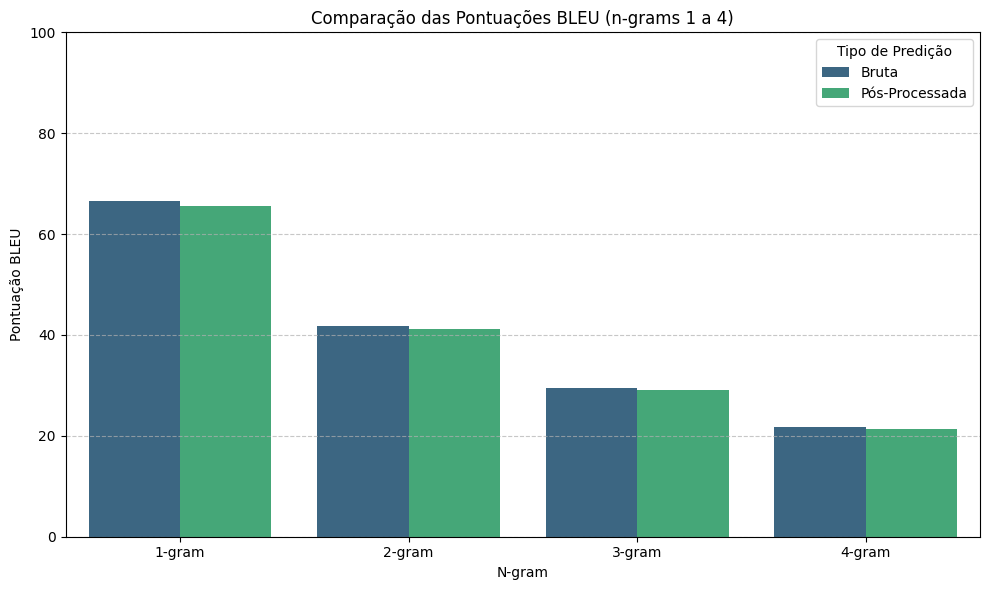

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract n-gram precisions
ngram_labels = ['1-gram', '2-gram', '3-gram', '4-gram']
raw_precisions = bleu_raw['precisions']
post_precisions = bleu_post['precisions']

# Create a DataFrame for plotting
data = {
    'N-gram': ngram_labels + ngram_labels,
    'Tipo de Predição': ['Bruta'] * len(ngram_labels) + ['Pós-Processada'] * len(ngram_labels),
    'Pontuação BLEU': raw_precisions + post_precisions
}
df_bleu_plot = pd.DataFrame(data)

# Plotting the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='N-gram', y='Pontuação BLEU', hue='Tipo de Predição', data=df_bleu_plot, palette='viridis')
plt.title('Comparação das Pontuações BLEU (n-grams 1 a 4)')
plt.ylabel('Pontuação BLEU')
plt.xlabel('N-gram')
plt.ylim(0, 100) # BLEU scores are usually between 0 and 100
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Tipo de Predição')
plt.tight_layout()
plt.show()

In [50]:
print("Iniciando a geração de predições para o conjunto de validação...")
print(f"Tamanho do conjunto de validação: {len(tokenized_dataset['validation'])} amostras")

# Gerar predições com batch_size maior para acelerar a inferência
val_preds_raw, val_refs = generate_predictions(
    tokenized_dataset["validation"],
    batch_size=256,
    max_new_tokens=512
)

# Pós-processamento das predições
val_preds_post = [postprocess_portuguese(p) for p in val_preds_raw]

# Calcular as pontuações do SacreBLEU
val_bleu_raw = sacrebleu.compute(
    predictions=[p.strip() for p in val_preds_raw],
    references=[[r.strip()] for r in val_refs]
)

val_bleu_post = sacrebleu.compute(
    predictions=[p.strip() for p in val_preds_post],
    references=[[r.strip()] for r in val_refs]
)

print("\n--- Resultados da Avaliação (Validação) ---")
print(f"SacreBLEU Bruto: {val_bleu_raw['score']:.2f}")
print(f"SacreBLEU Pós-processado: {val_bleu_post['score']:.2f}")

[transformers] Both `max_new_tokens` (=512) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Iniciando a geração de predições para o conjunto de validação...
Tamanho do conjunto de validação: 12735 amostras


[transformers] Both `max_new_tokens` (=512) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface


--- Resultados da Avaliação (Validação) ---
SacreBLEU Bruto: 34.25
SacreBLEU Pós-processado: 34.23


In [4]:
!pip install -q python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 13.8 MB/s eta 0:00:00


Agora, vamos reconfigurar os argumentos de treinamento para apontar para esta pasta do Google Drive em vez da pasta temporária `/content/`.

In [56]:
import pandas as pd
import IPython.display as display

# Compilando os resultados do Teste e Validação
tabela_resultados = pd.DataFrame({
    "N-gram": ["1-gram", "2-gram", "3-gram", "4-gram"],
    "Teste (Bruto)": [f"{p:.2f}" for p in bleu_raw["precisions"]],
    "Teste (Pós-processado)": [f"{p:.2f}" for p in bleu_post["precisions"]],
    "Validação (Bruto)": [f"{p:.2f}" for p in val_bleu_raw["precisions"]],
    "Validação (Pós-processado)": [f"{p:.2f}" for p in val_bleu_post["precisions"]]
})

print("--- Tabela de Resultados BLEU (1 a 4 n-grams) ---")
display.display(tabela_resultados)


--- Tabela de Resultados BLEU (1 a 4 n-grams) ---


,N-gram,Teste (Bruto),Teste (Pós-processado),Validação (Bruto),Validação (Pós-processado)
0,1-gram,66.51,65.54,66.52,65.58
1,2-gram,41.79,41.13,41.69,41.05
2,3-gram,29.52,29.01,29.53,29.04
3,4-gram,21.72,21.32,21.85,21.47


In [55]:
csv_dest_path = '/content/drive/MyDrive/Mestrado/Backup_Arquivos_Temporarios/tabela_resultados_bleu.csv'

tabela_resultados.to_csv(csv_dest_path, index=False)
print(f"Tabela de resultados BLEU exportada com sucesso para: {csv_dest_path}")

Tabela de resultados BLEU exportada com sucesso para: /content/drive/MyDrive/Mestrado/Backup_Arquivos_Temporarios/tabela_resultados_bleu.csv


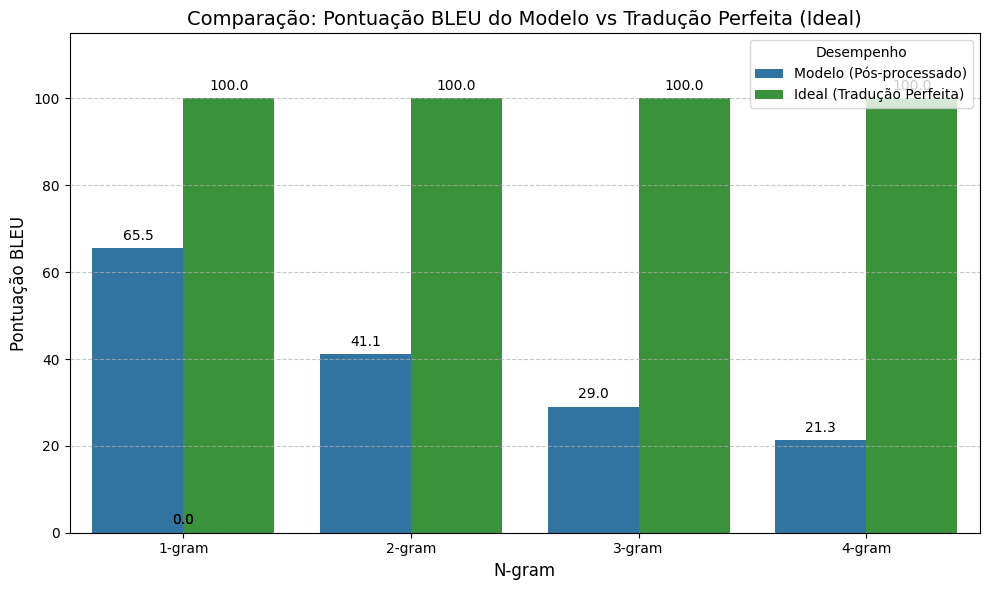

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Obtendo os scores pós-processados do teste (convertendo para float)
ngrams = ["1-gram", "2-gram", "3-gram", "4-gram"]
scores_teste = [float(x) for x in tabela_resultados["Teste (Pós-processado)"]]
scores_ideal = [100.0, 100.0, 100.0, 100.0]  # O BLEU máximo perfeito é 100

# Montando um DataFrame formatado para o Seaborn
df_comparacao = pd.DataFrame({
    "N-gram": ngrams * 2,
    "Referência": ["Modelo (Pós-processado)"] * 4 + ["Ideal (Tradução Perfeita)"] * 4,
    "Pontuação BLEU": scores_teste + scores_ideal
})

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_comparacao,
    x="N-gram",
    y="Pontuação BLEU",
    hue="Referência",
    palette=["#1f77b4", "#2ca02c"]
)

plt.title("Comparação: Pontuação BLEU do Modelo vs Tradução Perfeita (Ideal)", fontsize=14)
plt.ylim(0, 115) # Dá um espaço extra acima para os rótulos
plt.ylabel("Pontuação BLEU", fontsize=12)
plt.xlabel("N-gram", fontsize=12)

# Adicionando os números exatos acima de cada barra
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10)

plt.legend(title="Desempenho", loc="upper right")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [58]:
import IPython.display as display

# Selecionando uma amostra aleatória de 10 pares (referência vs predição pós-processada)
amostra_comparativa = resultados[['referencia', 'predicao_pos_processada']].sample(n=10, random_state=42)

print("--- Amostra Comparativa: Referência vs Predição (Pós-processada) ---")
display.display(amostra_comparativa)


--- Amostra Comparativa: Referência vs Predição (Pós-processada) ---


,referencia,predicao_pos_processada
12066,Eu vi um avião.,Vimos o avião.
11805,Vacina de febre amarela.,Vacinar febre amarela.
3707,Tom esqueceu alguma coisa?,Tom esqueceu alguma coisa?
2254,A identificação molecular dos moluscos é reali...,A identificação molecular dos moluscos é reali...
2531,Eisegese é frequentemente usada como um termo ...,Eisegeses frequentes são usadas como termo dep...
2963,A bainha da saia precisava de ajustes para um ...,A bainha e a saia precisam ser ajustadas para ...
173,Parcelamento de débitos do Simples Nacional,Parcelamento de débitos do Simples Nacional.
1346,"Em 1865, entre aproximadamente 12 e 17 de agos...","Em 1865, aproximadamente 12 e 17 de agosto com..."
8292,Podemos ir ali?,Posso ir lá?
1157,Nós nos perguntamos o porquê.,Nós nos perguntaremos por quê.


### Organização de Diretórios (Preparação para a próxima pipeline)

In [59]:
import os
import shutil

# Definindo os novos diretórios no Google Drive
artefatos_dir = '/content/drive/MyDrive/Mestrado/artefatos'
nova_pipeline_dir = '/content/drive/MyDrive/Mestrado/pipeline_galego_portugues'

# Criando as pastas
os.makedirs(artefatos_dir, exist_ok=True)
os.makedirs(nova_pipeline_dir, exist_ok=True)

# Copiando a base atual para a pasta de artefatos (para mantermos como VLibrasBD padrão)
base_origem = '/content/pt_br2libras_gloss.csv'
base_destino = os.path.join(artefatos_dir, 'VLibrasBD.csv')

if os.path.exists(base_origem) and not os.path.exists(base_destino):
    shutil.copy2(base_origem, base_destino)
    print(f"✅ Base copiada e padronizada em: {base_destino}")
elif os.path.exists(base_destino):
    print(f"✅ A base já existe em: {base_destino}")

print("Pastas configuradas com sucesso para os próximos testes:")
print(f"- {artefatos_dir}")
print(f"- {nova_pipeline_dir}")

✅ Base copiada e padronizada em: /content/drive/MyDrive/Mestrado/artefatos/VLibrasBD.csv
Pastas configuradas com sucesso para os próximos testes:
- /content/drive/MyDrive/Mestrado/artefatos
- /content/drive/MyDrive/Mestrado/pipeline_galego_portugues


### Análise de Erros: Predições de Baixa Pontuação
Vamos calcular o BLEU de cada frase individualmente para isolar as piores traduções e investigar os padrões de erro.

In [60]:
import sacrebleu
from tqdm.auto import tqdm
import IPython.display as display

print("Calculando o BLEU por sentença para 12.735 amostras...")
scores_individuais = []

# Calculamos o BLEU individual (Sentence BLEU)
for index, row in tqdm(resultados.iterrows(), total=len(resultados)):
    pred = str(row['predicao_pos_processada']).strip()
    ref = str(row['referencia']).strip()

    # sentence_bleu lida melhor com avaliações individuais
    score = sacrebleu.sentence_bleu(pred, [ref]).score
    scores_individuais.append(score)

resultados['bleu_score_individual'] = scores_individuais

# Filtrando casos com BLEU muito baixo (menor que 10)
# Filtramos notas exatamente 0.0 que geralmente são de frases vazias para focar em traduções erradas/alucinadas
piores_traducoes = resultados[(resultados['bleu_score_individual'] > 0.1) &
                              (resultados['bleu_score_individual'] < 10)].sort_values(by='bleu_score_individual')

print(f"\nEncontradas {len(piores_traducoes)} traduções com BLEU individual abaixo de 10.")
print("Abaixo estão 20 das piores traduções para inspecionarmos (podem indicar perda de contexto, erros de ENMs ou alucinação do modelo):\n")
display.display(piores_traducoes[['referencia', 'predicao_pos_processada', 'bleu_score_individual']].head(20))

Calculando o BLEU por sentença para 12.735 amostras...


  0%|          | 0/12735 [00:00<?, ?it/s]


Encontradas 1376 traduções com BLEU individual abaixo de 10.
Abaixo estão 20 das piores traduções para inspecionarmos (podem indicar perda de contexto, erros de ENMs ou alucinação do modelo):



,referencia,predicao_pos_processada,bleu_score_individual
4238,"Caímos, pois, em palavra e em pensamento e faz...","A palavra ""pensamento"" faz muito, muito, muito...",0.246480
8831,A empresa ganha uma nova visão valorizando tod...,As empresas novas valorizam o processo no Depa...,1.224819
130,"A, B, C, D, E, F, G, H, I, J, K, L, M, N, O, P...",A B C D E F G H I J K L M N O P Q R S T U V W ...,1.288358
5350,EMISSÃO E REGISTRO DE DIPLOMA E HISTÓRICO ESCO...,"Emissão e registro do Diploma, Histórico Escol...",1.506189
11827,FériasVistoViagemPassaporteLaissez-PasserDocum...,"Férias de vistos, viagens, passaportes, laisse...",1.650405
4080,Plutarco acrescenta ainda que o incidente — e ...,"Puta-se em um incidente em que Sula, senado ro...",1.737844
2038,CadastroPessoa JurídicaEmpresaAssociaçãoAssoci...,"Cadastro de pessoas jurídicas, empresas, assoc...",1.816085
3408,"Um representante da WHSmith disse: ""Nós previm...",O representante WSMIX disse que estava previst...,1.887465
11624,Evidências de estudos filogenéticos mostram qu...,A evidência de estudar filogenéticamente mostr...,1.924085
4512,Estas notas foram feitas e mantidas cotidianam...,"Esta nota mantém todo o dia de sua vida, Leona...",1.975618
